In [1]:
# ======================== 1. Imports ========================
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
# !pip install wordcloud
from wordcloud import WordCloud

# ML & Evaluation imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score


# Text processing tools
from autocorrect import Speller
from nltk.corpus import stopwords, wordnet
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

In [2]:
# ======================== 2. NLTK Setup ========================
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

Out[2]: True


True

In [3]:
# Printing the stopwords in english
print(stopwords.words('English'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [4]:
# ======================== 3. Load Dataset ========================
news_dataset = pd.read_csv("train.csv")

In [5]:
# Data Overview
print(news_dataset.info())
print(news_dataset.describe())
print(news_dataset.shape)
news_dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20800 non-null  int64 
 1   title   20242 non-null  object
 2   author  18843 non-null  object
 3   text    20761 non-null  object
 4   label   20800 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 812.6+ KB
None
                 id         label
count  20800.000000  20800.000000
mean   10399.500000      0.500625
std     6004.587135      0.500012
min        0.000000      0.000000
25%     5199.750000      0.000000
50%    10399.500000      1.000000
75%    15599.250000      1.000000
max    20799.000000      1.000000
(20800, 5)
Out[5]: 
   id  ... label
0   0  ...     1
1   1  ...     0
2   2  ...     1
3   3  ...     1
4   4  ...     1

[5 rows x 5 columns]


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [6]:
# Quick check for missing values
print("Missing Values Before:\n", news_dataset.isnull().sum())
news_dataset = news_dataset.fillna('')
print("\nMissing Values After:\n", news_dataset.isnull().sum())

Missing Values Before:
 id           0
title      558
author    1957
text        39
label        0
dtype: int64

Missing Values After:
 id        0
title     0
author    0
text      0
label     0
dtype: int64


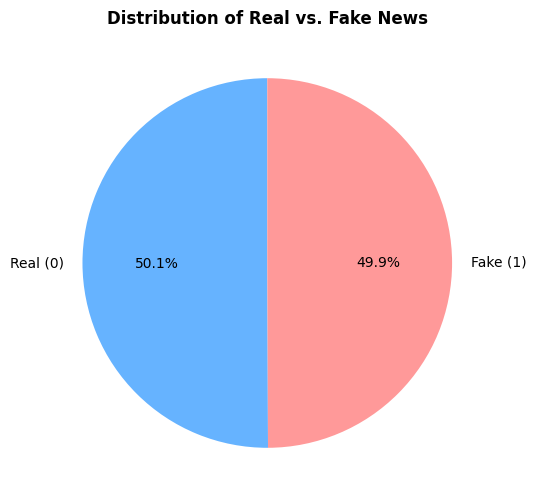

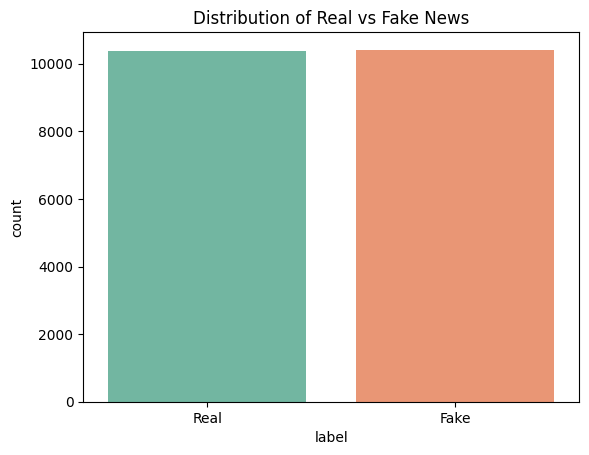

In [7]:
# Plotting label distribution
plt.figure(figsize=(6, 6))
labels = ['Real (0)', 'Fake (1)']
counts = news_dataset['label'].value_counts()
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Distribution of Real vs. Fake News', fontweight='bold')
plt.show()

sns.countplot(data=news_dataset, x='label', hue='label', legend=False, palette='Set2')
plt.title('Distribution of Real vs Fake News')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.show()


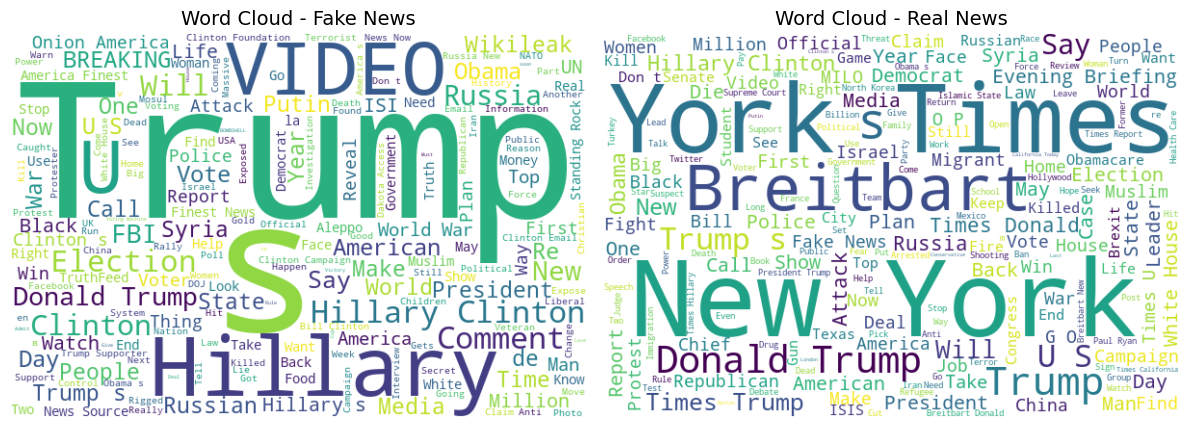

In [8]:
# Separate fake and real news
fake_news = news_dataset[news_dataset['label'] == 1]
real_news = news_dataset[news_dataset['label'] == 0]

# Join all text into one string
fake_words = ' '.join(fake_news['title'])
real_words = ' '.join(real_news['title'])

# Generate WordCloud
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
wc_fake = WordCloud(width=600, height=400, background_color='white').generate(fake_words)
plt.imshow(wc_fake, interpolation='bilinear')
plt.title("Word Cloud - Fake News", fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
wc_real = WordCloud(width=600, height=400, background_color='white').generate(real_words)
plt.imshow(wc_real, interpolation='bilinear')
plt.title("Word Cloud - Real News", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()


In [9]:
# ======================== 4. Text Preprocessing ========================
spell = Speller(lang='en')
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Helper to get correct POS tag for lemmatization
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [10]:
# Lemmatization pipeline
def lemmatize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = spell(text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    pos_tags = pos_tag(words)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return ' '.join(lemmatized)

# Stemming pipeline
def stem_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = spell(text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    stemmed = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed)

# Apply both processes
news_dataset['content_lemmatized'] = news_dataset['title'].apply(lemmatize_text)
news_dataset['content_stemmed'] = news_dataset['title'].apply(stem_text)

In [11]:
# ======================== 5. TF-IDF Vectorization ========================
vectorizer_stem = TfidfVectorizer()
vectorizer_lem = TfidfVectorizer()

X_stemmed = news_dataset['content_stemmed']
X_stemmed = vectorizer_stem.fit_transform(X_stemmed)
X_lemmatized = news_dataset['content_lemmatized']
X_lemmatized = vectorizer_lem.fit_transform(X_lemmatized)
Y = news_dataset['label'].values

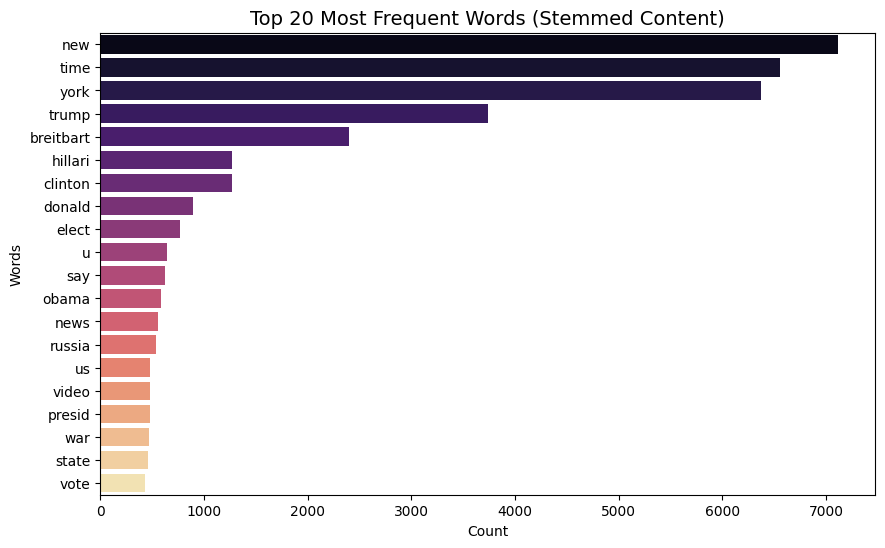

In [12]:
# Tokenize and collect words from both fake and real content
all_words = ' '.join(news_dataset['content_stemmed']).split()
word_freq = Counter(all_words)

# Get top 20 most common words
common_words = word_freq.most_common(20)

# Prepare data
words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, hue=words, legend=False, palette='magma')
plt.title("Top 20 Most Frequent Words (Stemmed Content)", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Words")
plt.show()

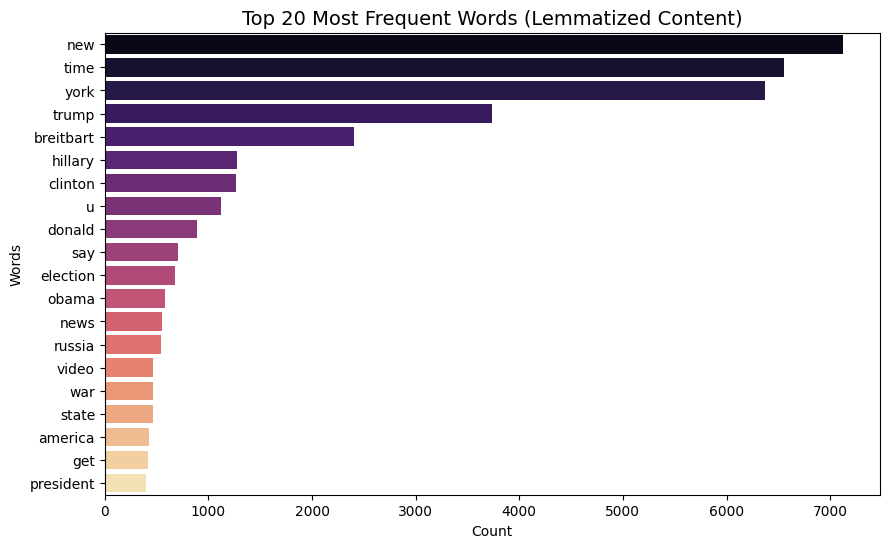

In [13]:
# Tokenize and collect words from both fake and real content
all_words = ' '.join(news_dataset['content_lemmatized']).split()
word_freq = Counter(all_words)

# Get top 20 most common words
common_words = word_freq.most_common(20)

# Prepare data
words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, hue=words, legend=False, palette='magma')
plt.title("Top 20 Most Frequent Words (Lemmatized Content)", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Words")
plt.show()

In [14]:
# ======================== 6. Train-Test Split ========================
# Splitting the data for stemming
X_train_stem, X_test_stem, y_train, y_test = train_test_split(
    X_stemmed, Y, test_size=0.2, stratify=Y, random_state=42
)

# Splitting the data for lemmatization
X_train_lem, X_test_lem, _, _ = train_test_split(
    X_lemmatized, Y, test_size=0.2, stratify=Y, random_state=42
)

from collections import Counter
print("Label distribution in y_train:", Counter(y_train))
print("Label distribution in y_test:", Counter(y_test))

Label distribution in y_train: Counter({np.int64(1): 8330, np.int64(0): 8310})
Label distribution in y_test: Counter({np.int64(1): 2083, np.int64(0): 2077})


In [15]:
# ======================== 7. Model Training & Evaluation ========================

# Logistic Regression
lr_stem = LogisticRegression(max_iter=1000)
lr_stem.fit(X_train_stem, y_train)
y_pred_lr_stem = lr_stem.predict(X_test_stem)

lr_lem = LogisticRegression(max_iter=1000)
lr_lem.fit(X_train_lem, y_train)
y_pred_lr_lem = lr_lem.predict(X_test_lem)

In [16]:
# SVM
svm_stem = SVC(kernel='linear', probability=True)
svm_stem.fit(X_train_stem, y_train)
y_pred_svm_stem = svm_stem.predict(X_test_stem)

svm_lem = SVC(kernel='linear', probability=True)
svm_lem.fit(X_train_lem, y_train)
y_pred_svm_lem = svm_lem.predict(X_test_lem)

In [17]:
# Random Forest
rf_stem = RandomForestClassifier(n_estimators=100, random_state=42)
rf_stem.fit(X_train_stem, y_train)
y_pred_rf_stem = rf_stem.predict(X_test_stem)

rf_lem = RandomForestClassifier(n_estimators=100, random_state=42)
rf_lem.fit(X_train_lem, y_train)
y_pred_rf_lem = rf_lem.predict(X_test_lem)

In [18]:
# ======================== 8. Classification Reports ========================
acc_lr_stem = accuracy_score(y_test, y_pred_lr_stem)
print("Logistic Regression (Stemming)")
print(f"Accuracy: {acc_lr_stem:.2%}")
print("Logistic Regression (Stemming):\n", classification_report(y_test, y_pred_lr_stem))
acc_lr_lem = accuracy_score(y_test, y_pred_lr_lem)
print("Logistic Regression (Lemmatization)")
print(f"Accuracy: {acc_lr_lem:.2%}")
print("Logistic Regression (Lemmatization):\n", classification_report(y_test, y_pred_lr_lem))

acc_svm_stem = accuracy_score(y_test, y_pred_svm_stem)
print("SVM (Stemming)")
print(f"Accuracy: {acc_svm_stem:.2%}")
print("SVM (Stemming):\n", classification_report(y_test, y_pred_svm_stem))
acc_svm_lem = accuracy_score(y_test, y_pred_svm_lem)
print("SVM (Lemmatization)")
print(f"Accuracy: {acc_svm_lem:.2%}")
print("SVM (Lemmatization):\n", classification_report(y_test, y_pred_svm_lem))

acc_rf_stem = accuracy_score(y_test, y_pred_rf_stem)
print("Random Forest (Stemming)")
print(f"Accuracy: {acc_rf_stem:.2%}")
print("Random Forest (Stemming):\n", classification_report(y_test, y_pred_rf_stem))
acc_rf_lem = accuracy_score(y_test, y_pred_rf_lem)
print("Random Forest (Lemmatization)")
print(f"Accuracy: {acc_rf_lem:.2%}")
print("Random Forest (Lemmatization):\n", classification_report(y_test, y_pred_rf_lem))

Logistic Regression (Stemming)
Accuracy: 91.95%
Logistic Regression (Stemming):
               precision    recall  f1-score   support

           0       0.98      0.86      0.91      2077
           1       0.87      0.98      0.92      2083

    accuracy                           0.92      4160
   macro avg       0.93      0.92      0.92      4160
weighted avg       0.93      0.92      0.92      4160

Logistic Regression (Lemmatization)
Accuracy: 92.04%
Logistic Regression (Lemmatization):
               precision    recall  f1-score   support

           0       0.98      0.86      0.92      2077
           1       0.87      0.98      0.93      2083

    accuracy                           0.92      4160
   macro avg       0.93      0.92      0.92      4160
weighted avg       0.93      0.92      0.92      4160

SVM (Stemming)
Accuracy: 92.79%
SVM (Stemming):
               precision    recall  f1-score   support

           0       0.97      0.88      0.92      2077
           1    

In [19]:
# ==================== Training and Saving Models ====================

# Save your vectorizers
from joblib import dump

# Save the trained vectorizers
dump(vectorizer_stem, 'vectorizer_stem.joblib')
dump(vectorizer_lem, 'vectorizer_lem.joblib')

# Save the trained models
dump(lr_stem, 'lr_stem_model.joblib')
dump(lr_lem, 'lr_lem_model.joblib')

dump(svm_stem, 'svm_stem_model.joblib')
dump(svm_lem, 'svm_lem_model.joblib')

dump(rf_stem, 'rf_stem_model.joblib')
dump(rf_lem, 'rf_lem_model.joblib')

print("All models and vectorizers saved successfully!")

All models and vectorizers saved successfully!


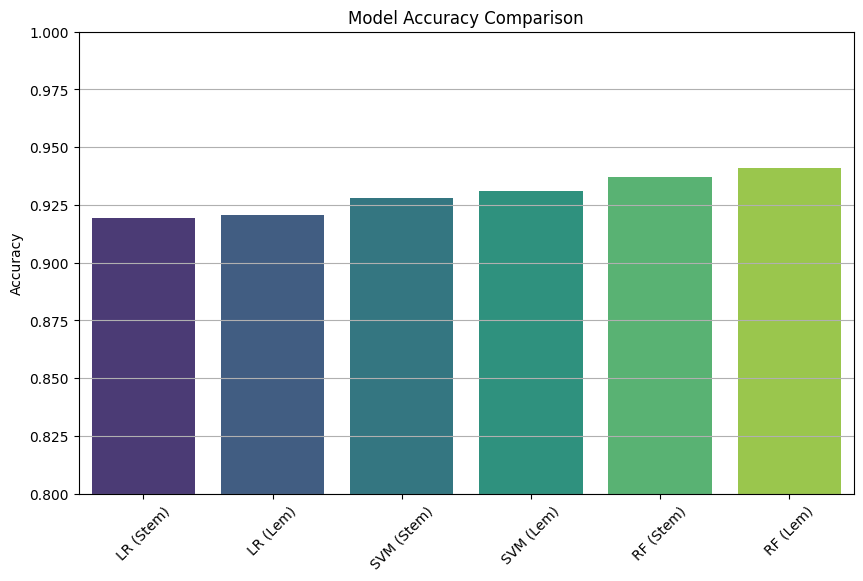

In [20]:
accuracies = [
    accuracy_score(y_test, y_pred_lr_stem),
    accuracy_score(y_test, y_pred_lr_lem),
    accuracy_score(y_test, y_pred_svm_stem),
    accuracy_score(y_test, y_pred_svm_lem),
    accuracy_score(y_test, y_pred_rf_stem),
    accuracy_score(y_test, y_pred_rf_lem)
]
models = [
    'LR (Stem)', 'LR (Lem)', 'SVM (Stem)', 'SVM (Lem)',
    'RF (Stem)', 'RF (Lem)'
]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, hue=models, legend=False, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.show()

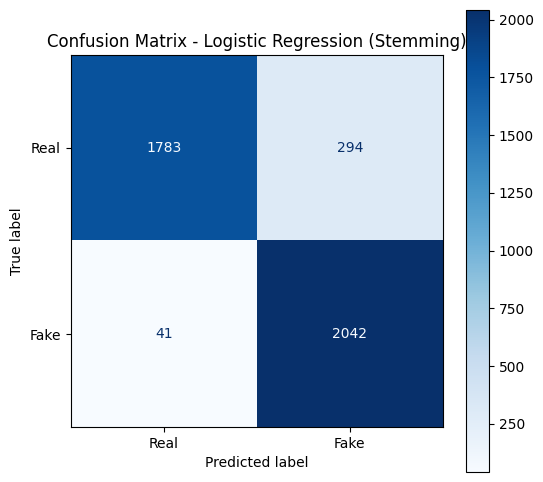

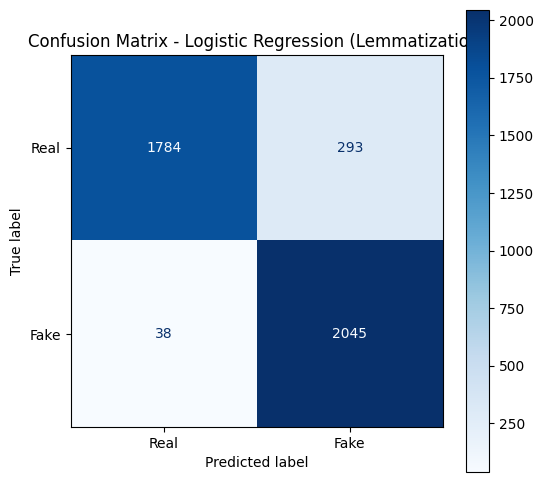

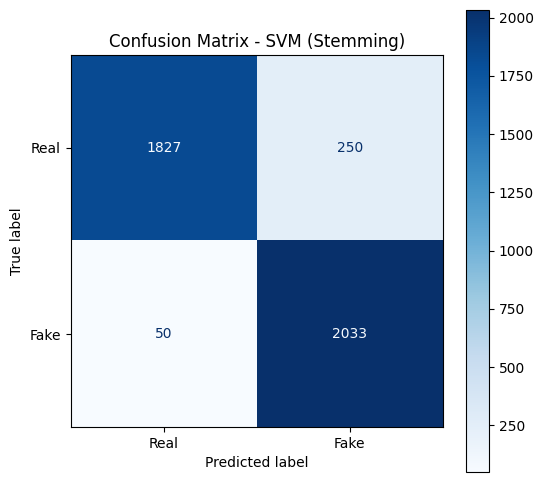

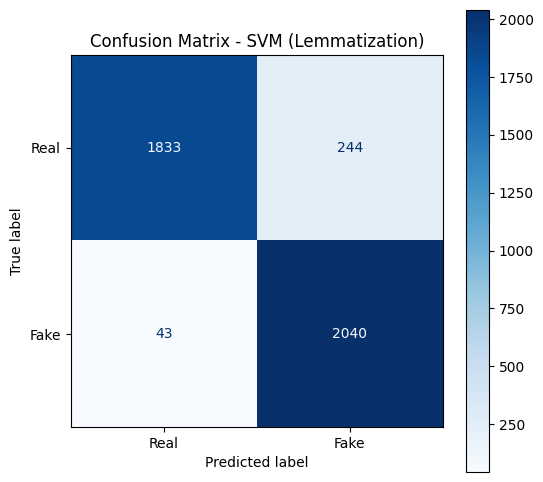

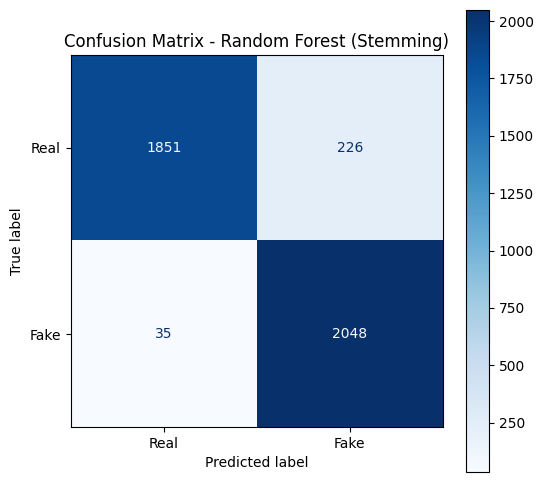

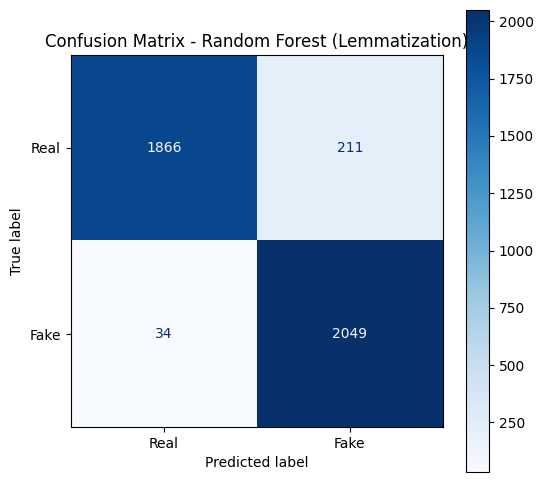

In [21]:
# ======================== 9. Confusion Matrices ========================

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', ax=ax)
    plt.title(title)
    plt.show()

plot_confusion(y_test, y_pred_lr_stem, 'Confusion Matrix - Logistic Regression (Stemming)')
plot_confusion(y_test, y_pred_lr_lem, 'Confusion Matrix - Logistic Regression (Lemmatization)')
plot_confusion(y_test, y_pred_svm_stem, 'Confusion Matrix - SVM (Stemming)')
plot_confusion(y_test, y_pred_svm_lem, 'Confusion Matrix - SVM (Lemmatization)')
plot_confusion(y_test, y_pred_rf_stem, 'Confusion Matrix - Random Forest (Stemming)')
plot_confusion(y_test, y_pred_rf_lem, 'Confusion Matrix - Random Forest (Lemmatization)')


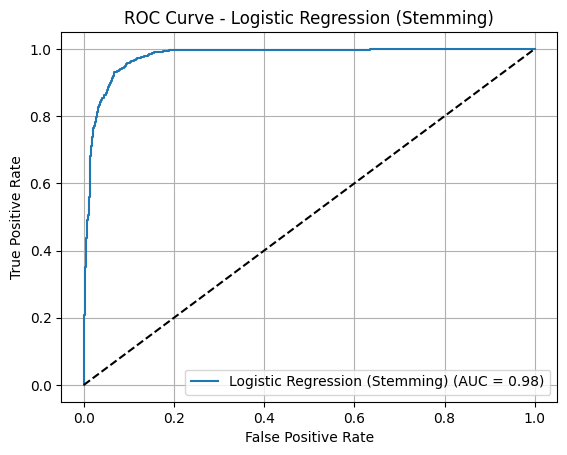

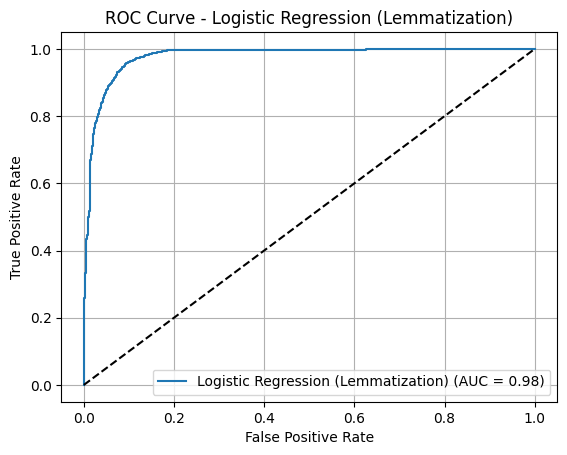

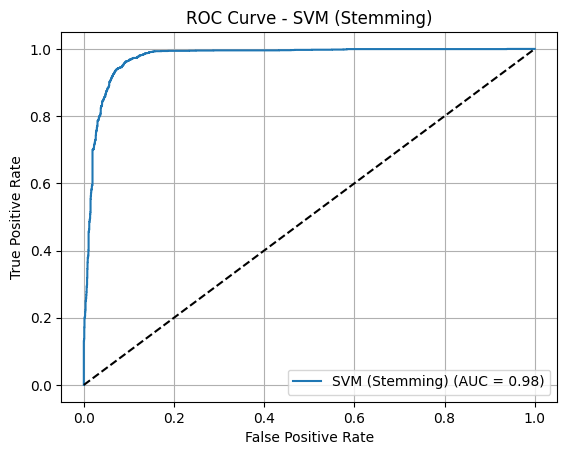

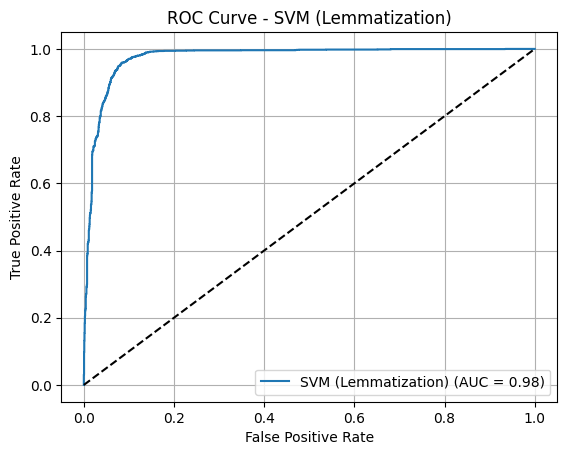

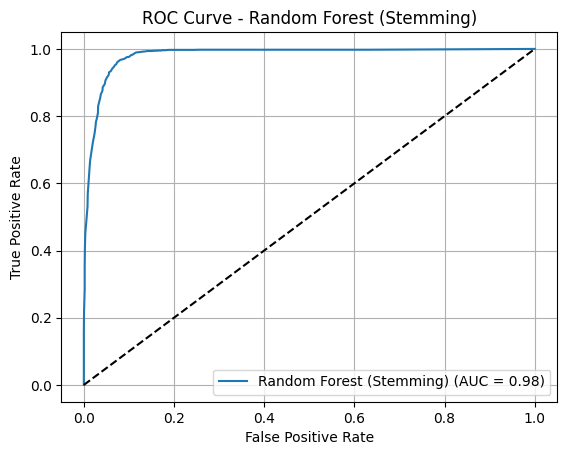

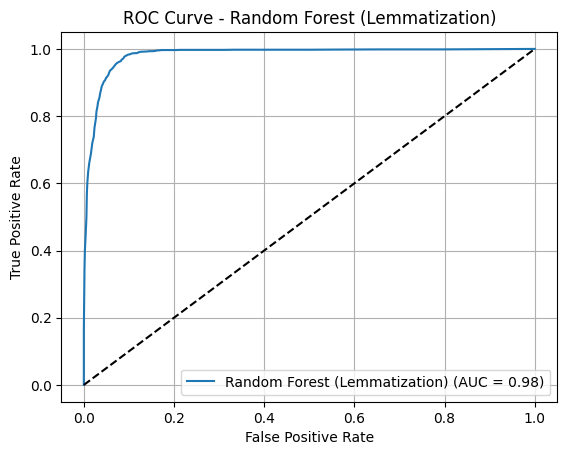

In [22]:

# ======================== 10. ROC Curves ========================

def plot_roc(model, X_test, y_test, label):
    y_probs = model.predict_proba(X_test)[:, 1]  # Get probability for class 1 (Fake)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

plot_roc(lr_stem, X_test_stem, y_test, "Logistic Regression (Stemming)")
plot_roc(lr_lem, X_test_lem, y_test, "Logistic Regression (Lemmatization)")
plot_roc(svm_stem, X_test_stem, y_test, "SVM (Stemming)")
plot_roc(svm_lem, X_test_lem, y_test, "SVM (Lemmatization)")
plot_roc(rf_stem, X_test_stem, y_test, "Random Forest (Stemming)")
plot_roc(rf_lem, X_test_lem, y_test, "Random Forest (Lemmatization)")

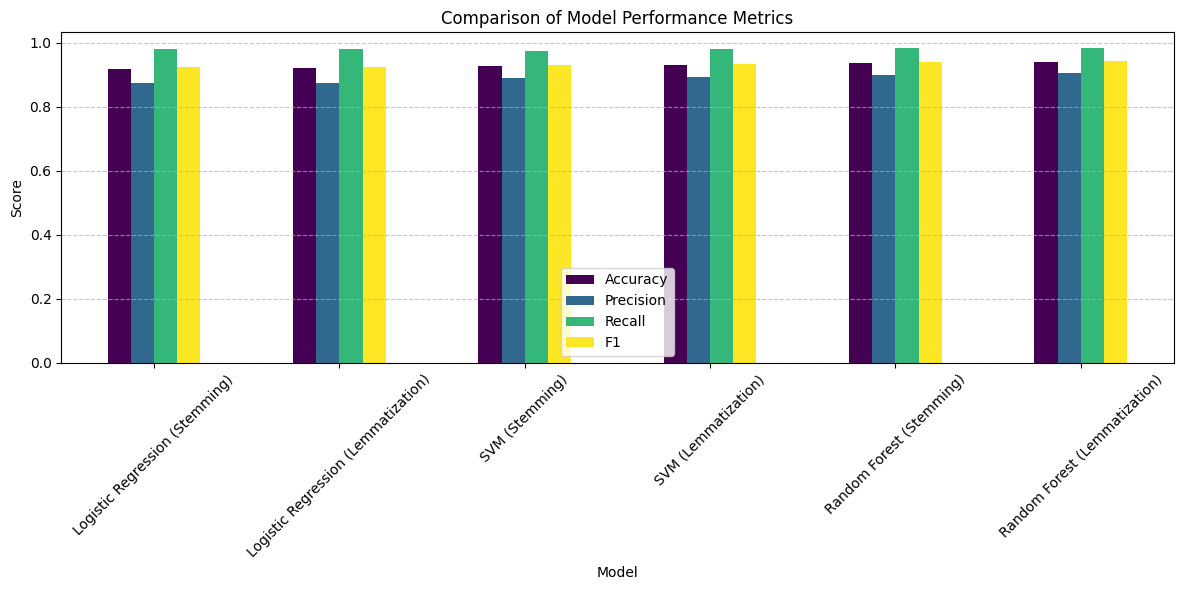

In [23]:
# Prepare model names and predictions
models = [
    "Logistic Regression (Stemming)", 
    "Logistic Regression (Lemmatization)", 
    "SVM (Stemming)", 
    "SVM (Lemmatization)", 
    "Random Forest (Stemming)", 
    "Random Forest (Lemmatization)"
]
predictions = [
    y_pred_lr_stem,
    y_pred_lr_lem,
    y_pred_svm_stem,
    y_pred_svm_lem,
    y_pred_rf_stem,
    y_pred_rf_lem
]

# Collect metrics in a list
metrics_list = []

for name, pred in zip(models, predictions):
    # Create a dictionary of scores for this model
    metrics_dict = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    }
    metrics_list.append(metrics_dict)

# Convert list of dicts into a DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Set model names as index for plotting
metrics_df.set_index('Model', inplace=True)
# Plotting the comparison graph
metrics_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Comparison of Model Performance Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


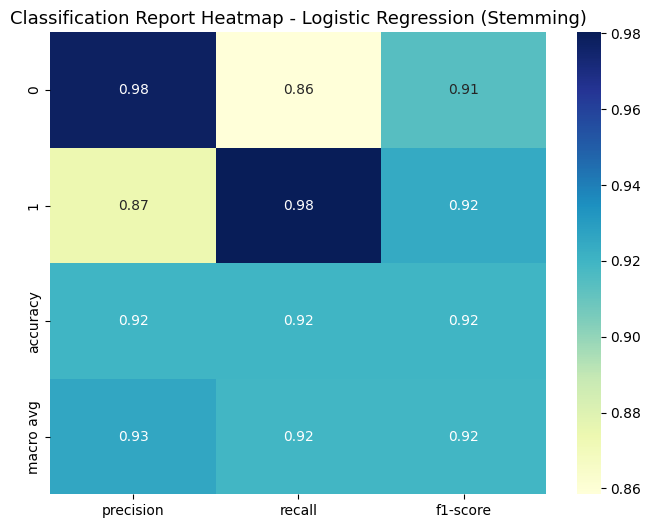

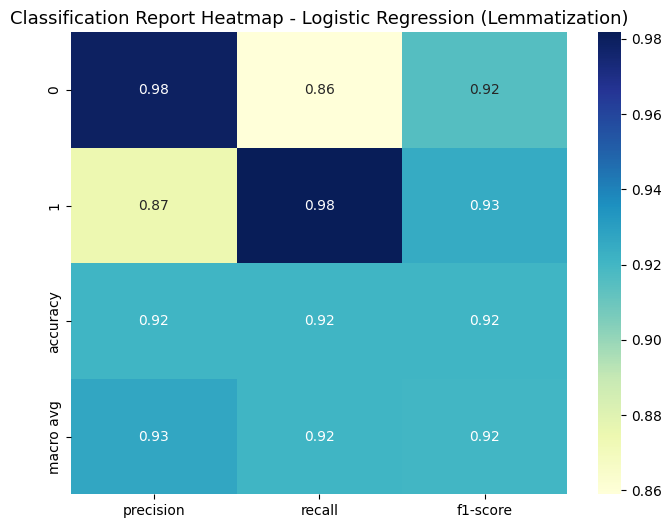

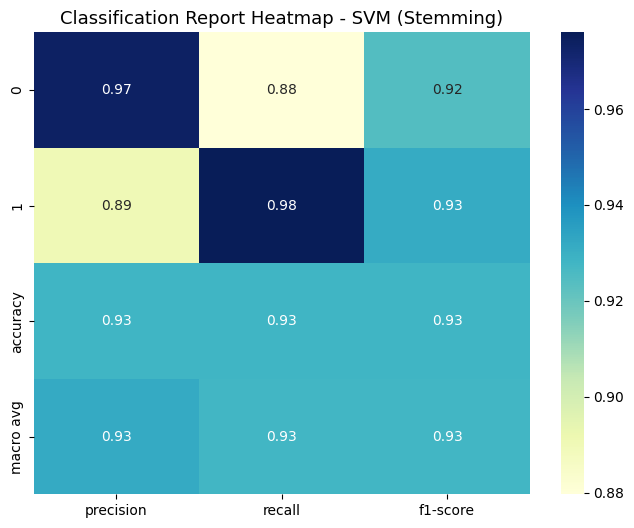

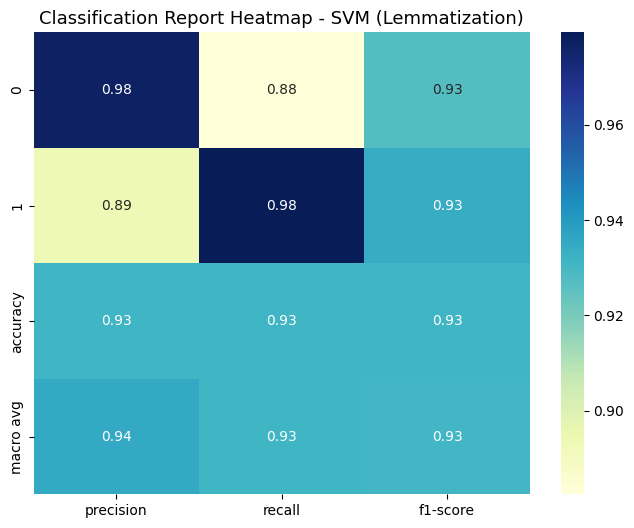

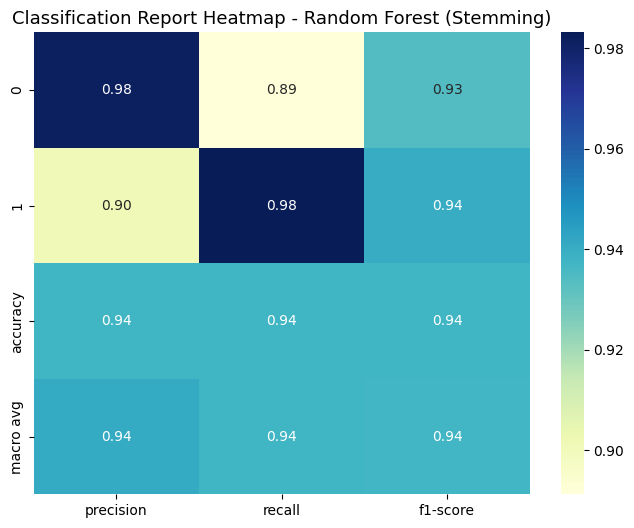

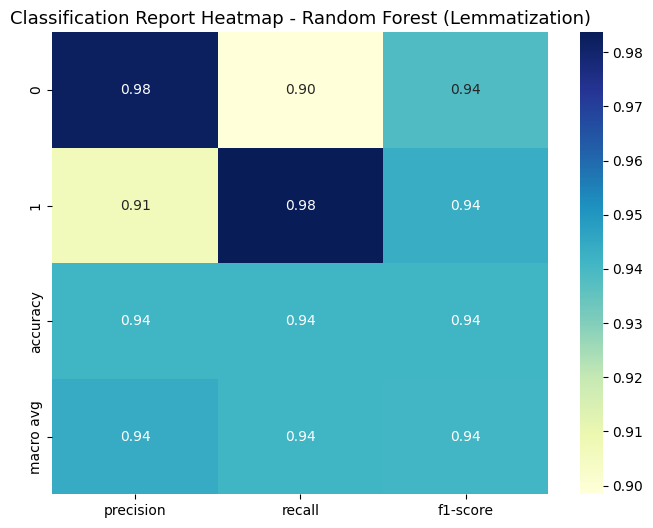

In [24]:
# Create a list of model predictions and their names
model_predictions = [
    ("Logistic Regression (Stemming)", y_pred_lr_stem),
    ("Logistic Regression (Lemmatization)", y_pred_lr_lem),
    ("SVM (Stemming)", y_pred_svm_stem),
    ("SVM (Lemmatization)", y_pred_svm_lem),
    ("Random Forest (Stemming)", y_pred_rf_stem),
    ("Random Forest (Lemmatization)", y_pred_rf_lem),
]

# Loop through each model and create a heatmap for its classification report
for model_name, y_pred in model_predictions:
    # Generate classification report dictionary
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Convert the dictionary to a DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Drop support and average rows for clean heatmap
    report_df = report_df.iloc[:-1, :-1]
    
    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True)
    plt.title(f"Classification Report Heatmap - {model_name}", fontsize=13)
    plt.show()


==== Plotting Train vs Test Loss for All Models ====


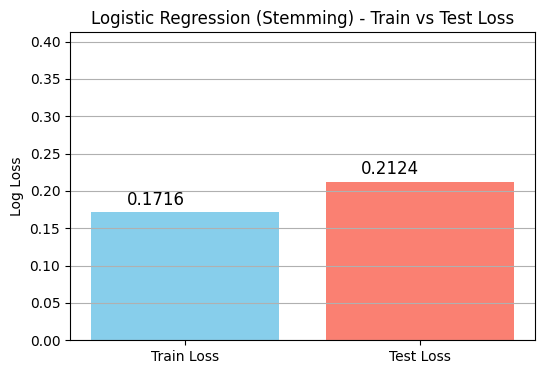

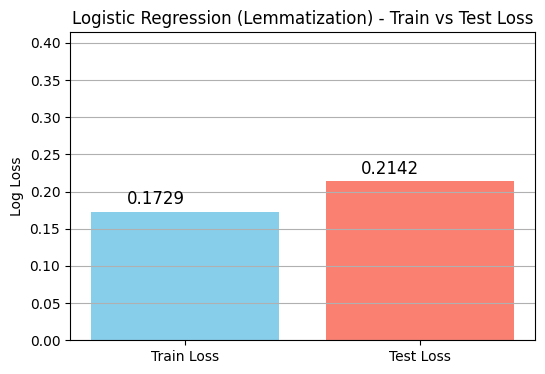

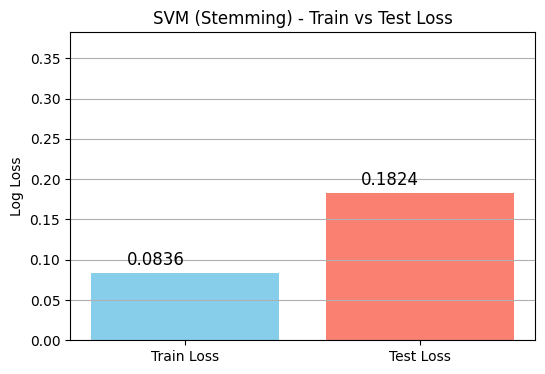

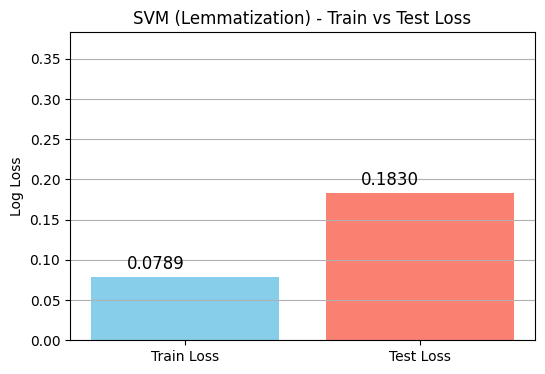

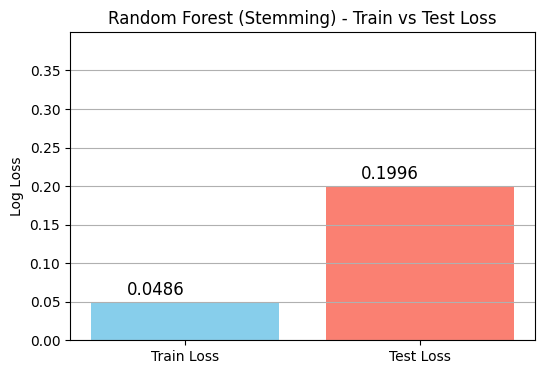

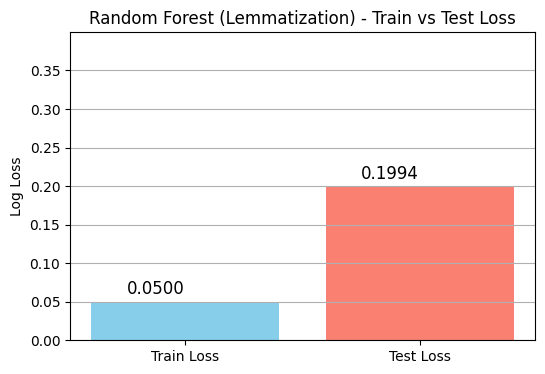

In [25]:
from sklearn.metrics import log_loss
import numpy as np

# Helper to compute train/test loss
def compute_and_plot_loss(model, X_train, X_test, y_train, y_test, model_name):
    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)
    
    train_loss = log_loss(y_train, y_train_prob)
    test_loss = log_loss(y_test, y_test_prob)

    plt.figure(figsize=(6, 4))
    bars = plt.bar(['Train Loss', 'Test Loss'], [train_loss, test_loss], color=['skyblue', 'salmon'])
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + 0.15, yval + 0.01, f'{yval:.4f}', fontsize=12)
    plt.title(f'{model_name} - Train vs Test Loss')
    plt.ylabel("Log Loss")
    plt.ylim(0, max(train_loss, test_loss) + 0.2)
    plt.grid(axis='y')
    plt.show()

print("==== Plotting Train vs Test Loss for All Models ====")
# Logistic Regression
compute_and_plot_loss(lr_stem, X_train_stem, X_test_stem, y_train, y_test, "Logistic Regression (Stemming)")
compute_and_plot_loss(lr_lem, X_train_lem, X_test_lem, y_train, y_test, "Logistic Regression (Lemmatization)")

# SVM
compute_and_plot_loss(svm_stem, X_train_stem, X_test_stem, y_train, y_test, "SVM (Stemming)")
compute_and_plot_loss(svm_lem, X_train_lem, X_test_lem, y_train, y_test, "SVM (Lemmatization)")

# Random Forest
compute_and_plot_loss(rf_stem, X_train_stem, X_test_stem, y_train, y_test, "Random Forest (Stemming)")
compute_and_plot_loss(rf_lem, X_train_lem, X_test_lem, y_train, y_test, "Random Forest (Lemmatization)")


In [26]:
# ======================== 12. Predictive System Example ========================
X_new = ["Cats Now Eligible for College Degrees After Viral Online Petition"]
X_new_stemmed = [stem_text(text) for text in X_new]
X_new_transformed = vectorizer_stem.transform(X_new_stemmed)
prediction = rf_stem.predict(X_new_transformed)

print("Prediction for new headline:", "Fake" if prediction[0] == 1 else "Real")


Prediction for new headline: Fake
